# Laptop Price Prediction using Multiple Linear Regression
### Developed by: Certified Generative AI Developer
 
**Project Objective:** Build a predictive model to estimate laptop prices based on technical specifications using Ordinary Least Squares (OLS) and Stochastic Gradient Descent (SGD) optimization techniques.

In [ ]:
 
#  STEP 1: IMPORT LIBRARIES & LOAD DATA
 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning and evaluation utilities
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

# Load dataset from the Kaggle input repository
df = pd.read_csv('laptop_data_cleaned.csv')

# Preview the first 5 rows of the dataset
df.head()

,Company,TypeName,Ram,Weight,Price,TouchScreen,Ips,Ppi,Cpu_brand,HDD,SSD,Gpu_brand,Os
0,Apple,Ultrabook,8,1.37,11.175755,0,1,226.983005,Intel Core i5,0,128,Intel,Mac
1,Apple,Ultrabook,8,1.34,10.776777,0,0,127.677940,Intel Core i5,0,0,Intel,Mac
2,HP,Notebook,8,1.86,10.329931,0,0,141.211998,Intel Core i5,0,256,Intel,Others
3,Apple,Ultrabook,16,1.83,11.814476,0,1,220.534624,Intel Core i7,0,512,AMD,Mac
4,Apple,Ultrabook,8,1.37,11.473101,0,1,226.983005,Intel Core i5,0,256,Intel,Mac


## Step 2: Exploratory Data Analysis & Data Inspection
Inspecting data dimensions, structural shape, data types, and checking for missing values.

In [6]:
 
# STEP 2: DATA INSPECTION
 

# Display structural shape of the dataframe
print("Dataset Structural Shape:", df.shape)

# Display columns, non-null counts, and data types
df.info()

# Verify if there are any missing/null values
print("\nMissing Values Count per Column:\n", df.isnull().sum())

Dataset Structural Shape: (1273, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1273 entries, 0 to 1272
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Company      1273 non-null   object 
 1   TypeName     1273 non-null   object 
 2   Ram          1273 non-null   int64  
 3   Weight       1273 non-null   float64
 4   Price        1273 non-null   float64
 5   TouchScreen  1273 non-null   int64  
 6   Ips          1273 non-null   int64  
 7   Ppi          1273 non-null   float64
 8   Cpu_brand    1273 non-null   object 
 9   HDD          1273 non-null   int64  
 10  SSD          1273 non-null   int64  
 11  Gpu_brand    1273 non-null   object 
 12  Os           1273 non-null   object 
dtypes: float64(3), int64(5), object(5)
memory usage: 129.4+ KB

Missing Values Count per Column:
 Company        0
TypeName       0
Ram            0
Weight         0
Price          0
TouchScreen    0
Ips            0
Ppi     

## Step 3: Data Preprocessing & Categorical Encoding
Transforming categorical/text features into mathematical binary columns using One-Hot Encoding to avoid the Dummy Variable Trap.

In [7]:
 
# STEP 3: CATEGORICAL DATA ENCODING
 

# Automatically capture all object/categorical columns for encoding
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns identified for encoding:", categorical_cols)

# Apply One-Hot Encoding and drop the first dummy variable to avoid collinearity
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Preview structural transformations
df_encoded.head()

Categorical columns identified for encoding: ['Company', 'TypeName', 'Cpu_brand', 'Gpu_brand', 'Os']


,Ram,Weight,Price,TouchScreen,Ips,Ppi,HDD,SSD,Company_Apple,Company_Asus,...,TypeName_Ultrabook,TypeName_Workstation,Cpu_brand_Intel Core i3,Cpu_brand_Intel Core i5,Cpu_brand_Intel Core i7,Cpu_brand_Other Intel Processor,Gpu_brand_Intel,Gpu_brand_Nvidia,Os_Others,Os_Windows
0,8,1.37,11.175755,0,1,226.983005,0,128,True,False,...,True,False,False,True,False,False,True,False,False,False
1,8,1.34,10.776777,0,0,127.677940,0,0,True,False,...,True,False,False,True,False,False,True,False,False,False
2,8,1.86,10.329931,0,0,141.211998,0,256,False,False,...,False,False,False,True,False,False,True,False,True,False
3,16,1.83,11.814476,0,1,220.534624,0,512,True,False,...,True,False,False,False,True,False,False,False,False,False
4,8,1.37,11.473101,0,1,226.983005,0,256,True,False,...,True,False,False,True,False,False,True,False,False,False


## Step 4: Model Training - Ordinary Least Squares (OLS)
Splitting the data matrix into 80% training and 20% testing sets, then training a baseline Multiple Linear Regression model via analytical closed-form solution.

In [8]:
 
# STEP 4: TRAIN-TEST SPLIT & OLS MODEL
 

# Separate independent variables (X) from the target output variable (y)
X = df_encoded.drop(columns=['Price'])
y = df_encoded['Price']

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Feature Set Matrix Size:", X_train.shape)
print("Testing Feature Set Matrix Size:", X_test.shape)

# Initialize and fit the Ordinary Least Squares Linear Regression model
ols_model = LinearRegression()
ols_model.fit(X_train, y_train)

# Evaluate OLS predictions
y_pred_ols = ols_model.predict(X_test)
mae_ols = mean_absolute_error(y_test, y_pred_ols)
r2_ols = r2_score(y_test, y_pred_ols)

print("\n--- OLS Model Performance Baseline ---")
print(f"Mean Absolute Error (MAE): {mae_ols:.2f}")
print(f"R2 Score (Variance Explained): {r2_ols:.4f}")

Training Feature Set Matrix Size: (1018, 38)
Testing Feature Set Matrix Size: (255, 38)

--- OLS Model Performance Baseline ---
Mean Absolute Error (MAE): 0.22
R2 Score (Variance Explained): 0.8048


## Step 5: Optimization - Stochastic Gradient Descent (SGD)
Scaling features uniformly using StandardScaler to ensure stable convergence, followed by optimizing the loss landscape using SGD.

In [9]:
 
# STEP 5: GRADIENT DESCENT OPTIMIZATION
 

# Scale features uniformly to support steady Gradient Descent step convergence
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and fit SGDRegressor with fixed learning rate (eta0) and maximum epochs
sgd_model = SGDRegressor(max_iter=2000, eta0=0.01, random_state=42)
sgd_model.fit(X_train_scaled, y_train)

# Evaluate SGD predictions
y_pred_sgd = sgd_model.predict(X_test_scaled)
mae_sgd = mean_absolute_error(y_test, y_pred_sgd)
r2_sgd = r2_score(y_test, y_pred_sgd)

print("--- Gradient Descent (SGD) Performance ---")
print(f"Mean Absolute Error (MAE): {mae_sgd:.2f}")
print(f"R2 Score (Variance Explained): {r2_sgd:.4f}")

--- Gradient Descent (SGD) Performance ---
Mean Absolute Error (MAE): 0.22
R2 Score (Variance Explained): 0.8049


## Step 6: Model Diagnostics & Feature Importance Visualizations
Plotting residuals to validate structural model assumptions, and mapping the top coefficients driving laptop market pricing.

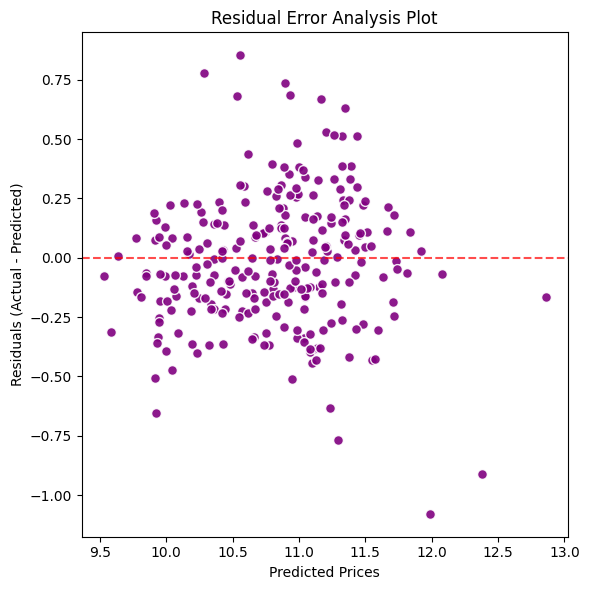

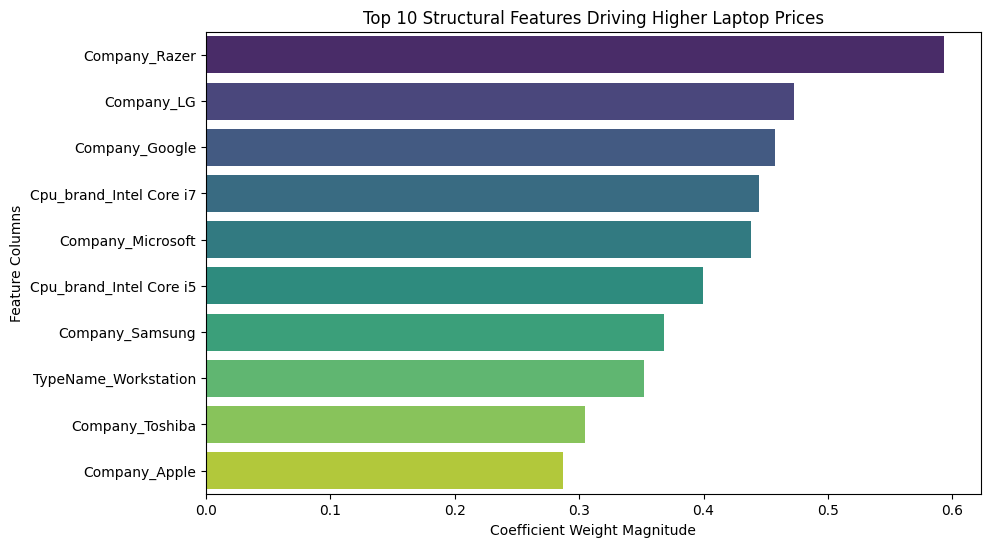

In [10]:
 
# STEP 6: DIAGNOSTICS & VISUALIZATIONS
 

# 1. Plotting Model Residuals (Errors)
residuals = y_test - y_pred_ols
plt.figure(figsize=(6, 6))
plt.scatter(x=y_pred_ols, y=residuals, color='purple', edgecolors='white', s=50, alpha=0.9)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)
plt.title('Residual Error Analysis Plot')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals (Actual - Predicted)')
plt.tight_layout()
plt.show()

# 2. Extracting Top 10 Feature Coefficients (Drivers)
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': ols_model.coef_})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df.head(10), hue='Feature', palette='viridis', legend=False)
plt.title('Top 10 Structural Features Driving Higher Laptop Prices')
plt.xlabel('Coefficient Weight Magnitude')
plt.ylabel('Feature Columns')
plt.show()